<a href="https://www.kaggle.com/code/lalit7881/social-media-analysis-ai-trends-eda-100?scriptVersionId=337066949" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dreamtensor/social-media-sentiment-analysisai-trend-2026/Social_Media_Sentiment_Analysis_AI_Trends_2026.csv


In [2]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # ensure non-interactive backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # switch backend if only plt is imported

# Inline plotting even though we switch to a non-interactive backend for saving plots
%matplotlib inline

import seaborn as sns

# Machine learning libraries for predictive analysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

print('Libraries imported and setup complete.')

Libraries imported and setup complete.


## Loading dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/dreamtensor/social-media-sentiment-analysisai-trend-2026/Social_Media_Sentiment_Analysis_AI_Trends_2026.csv")

In [4]:
df.head()

,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,day_of_week,is_trending_topic,topic_category,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url
0,YouTube,YO_100000,user_2679,rxckafna,True,375410,Germany,I don’t agree with this at all.,ur,"#news,#update",...,Wed,True,Technology,Positive,0.82,Sad,0.10,False,True,https://www.youtube.com
1,Reddit,RE_100001,user_3045,zjovqwps,True,346702,UK,Worst decision ever made.,fr,"#trending,#ai",...,Tue,False,Sports,Neutral,-0.02,Angry,0.67,True,True,https://www.reddit.com
2,YouTube,YO_100002,user_4598,rvufaigf,False,111487,Germany,This trend is getting out of hand.,de,"#news,#update",...,Fri,False,Finance,Positive,0.62,Neutral,0.43,False,False,https://www.youtube.com
3,Twitter,TW_100003,user_3504,qukbjznz,True,356674,Germany,Pretty neutral about the update.,en,"#trending,#ai",...,Thu,True,Finance,Neutral,0.14,Sad,0.97,True,True,https://www.twitter.com
4,YouTube,YO_100004,user_3646,ounaiayw,False,125551,USA,"Loved the explanation, very helpful.",es,"#trending,#ai",...,Sun,True,Technology,Neutral,-0.05,Fear,0.95,True,False,https://www.youtube.com


In [5]:
df.tail()

,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,day_of_week,is_trending_topic,topic_category,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url
2195,Twitter,TW_102195,user_5562,wbmdjeyg,False,416073,Canada,This is absolutely amazing!,es,"#trending,#ai",...,Sat,True,Climate,Neutral,0.07,Fear,0.75,True,False,https://www.twitter.com
2196,Twitter,TW_102196,user_7076,jgagwoun,False,101979,Canada,I’m confused about the announcement.,ur,"#news,#update",...,Wed,False,Technology,Neutral,0.15,Fear,0.95,False,True,https://www.twitter.com
2197,YouTube,YO_102197,user_9327,ubafeuzh,True,386908,UK,"Not bad, but could be better.",ur,"#trending,#ai",...,Mon,False,Sports,Negative,-0.90,Fear,0.25,True,False,https://www.youtube.com
2198,Reddit,RE_102198,user_4002,zahccrkp,False,266478,UK,I’m confused about the announcement.,es,"#trending,#ai",...,Sun,True,Finance,Positive,0.91,Fear,0.43,True,False,https://www.reddit.com
2199,YouTube,YO_102199,user_4688,tolbdysn,False,338860,India,This is absolutely amazing!,fr,"#news,#update",...,Sat,True,Finance,Neutral,-0.19,Angry,0.13,False,False,https://www.youtube.com


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   platform              2200 non-null   object 
 1   post_id               2200 non-null   object 
 2   user_id               2200 non-null   object 
 3   username              2200 non-null   object 
 4   user_verified         2200 non-null   bool   
 5   user_followers_count  2200 non-null   int64  
 6   user_location         2200 non-null   object 
 7   post_text             2200 non-null   object 
 8   language              2200 non-null   object 
 9   hashtags              2200 non-null   object 
 10  mentions              872 non-null    object 
 11  post_length           2200 non-null   int64  
 12  like_count            2200 non-null   int64  
 13  comment_count         2200 non-null   int64  
 14  share_count           2200 non-null   int64  
 15  engagement_score     

In [7]:
df.isnull().sum()

platform                   0
post_id                    0
user_id                    0
username                   0
user_verified              0
user_followers_count       0
user_location              0
post_text                  0
language                   0
hashtags                   0
mentions                1328
post_length                0
like_count                 0
comment_count              0
share_count                0
engagement_score           0
posted_datetime            0
day_of_week                0
is_trending_topic          0
topic_category             0
sentiment_label            0
sentiment_score            0
emotion_label              0
toxicity_score             0
sarcasm_detected           0
spam_flag                  0
data_source_url            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

platform                 object
post_id                  object
user_id                  object
username                 object
user_verified              bool
user_followers_count      int64
user_location            object
post_text                object
language                 object
hashtags                 object
mentions                 object
post_length               int64
like_count                int64
comment_count             int64
share_count               int64
engagement_score        float64
posted_datetime          object
day_of_week              object
is_trending_topic          bool
topic_category           object
sentiment_label          object
sentiment_score         float64
emotion_label            object
toxicity_score          float64
sarcasm_detected           bool
spam_flag                  bool
data_source_url          object
dtype: object

In [10]:
df.shape

(2200, 27)

In [11]:
df.columns

Index(['platform', 'post_id', 'user_id', 'username', 'user_verified',
       'user_followers_count', 'user_location', 'post_text', 'language',
       'hashtags', 'mentions', 'post_length', 'like_count', 'comment_count',
       'share_count', 'engagement_score', 'posted_datetime', 'day_of_week',
       'is_trending_topic', 'topic_category', 'sentiment_label',
       'sentiment_score', 'emotion_label', 'toxicity_score',
       'sarcasm_detected', 'spam_flag', 'data_source_url'],
      dtype='object')

In [12]:
df.nunique()

platform                   3
post_id                 2200
user_id                 1950
username                2200
user_verified              2
user_followers_count    2192
user_location              6
post_text                 10
language                   5
hashtags                   2
mentions                   1
post_length                7
like_count              2081
comment_count           1774
share_count             1565
engagement_score         101
posted_datetime          675
day_of_week                7
is_trending_topic          2
topic_category             7
sentiment_label            3
sentiment_score          183
emotion_label              5
toxicity_score           101
sarcasm_detected           2
spam_flag                  2
data_source_url            3
dtype: int64

In [13]:
import plotly.express as px
import plotly.graph_objects as go

from wordcloud import WordCloud

## EDA

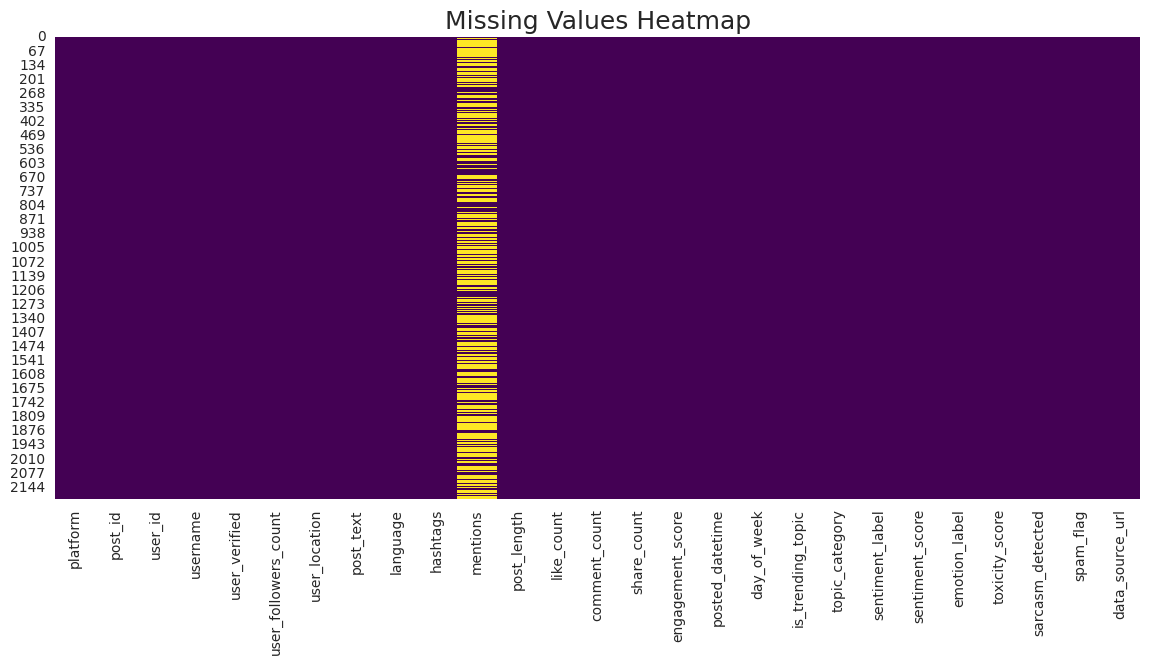

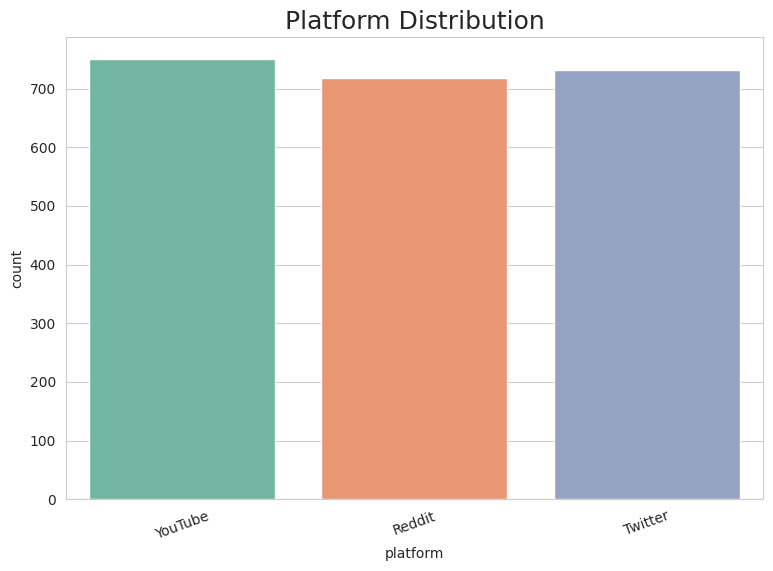

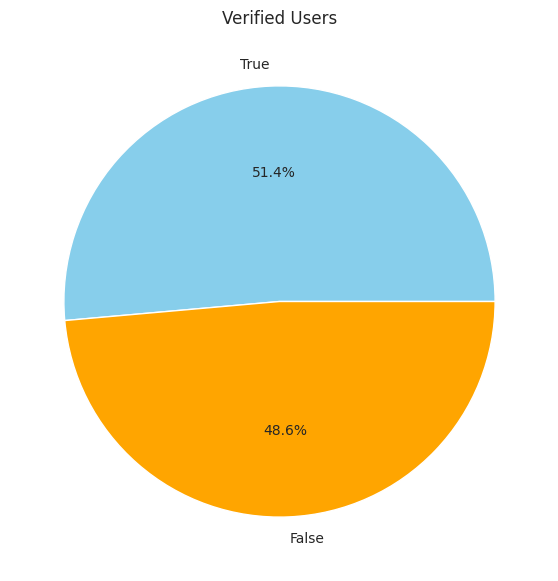

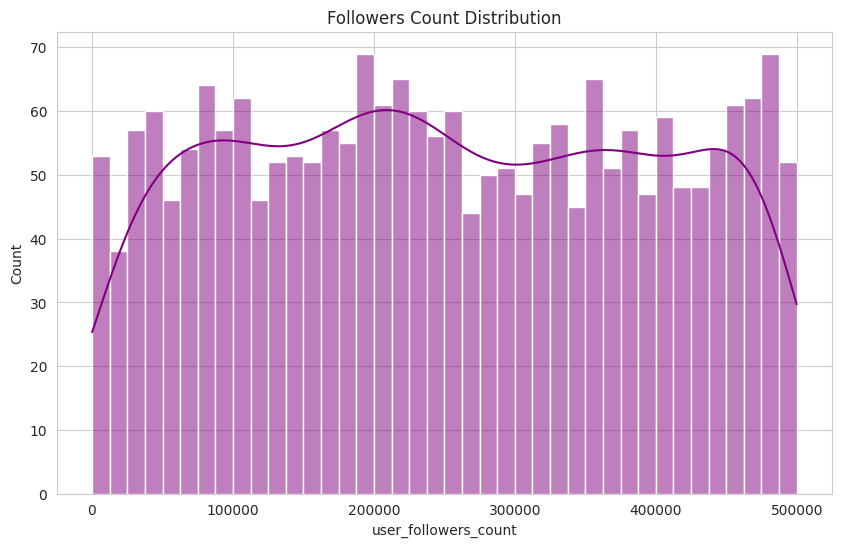

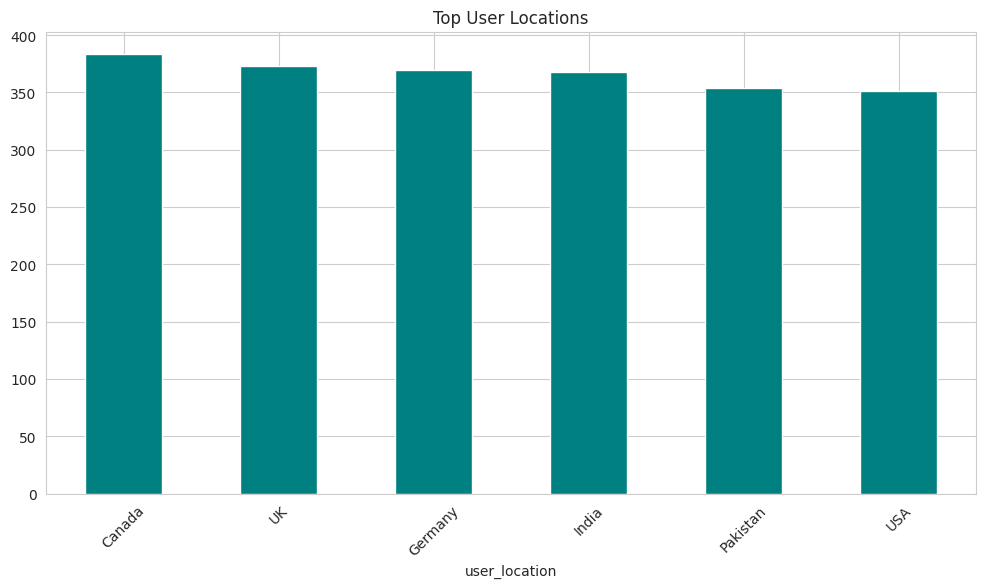

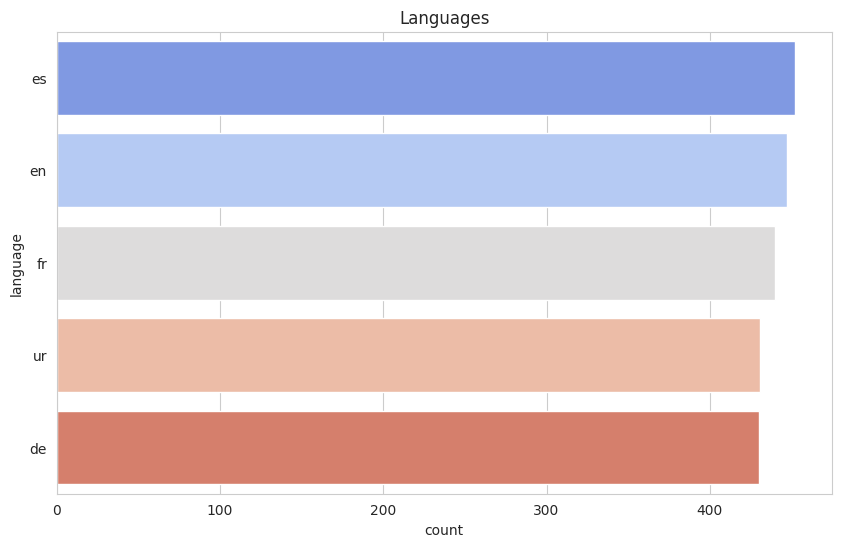

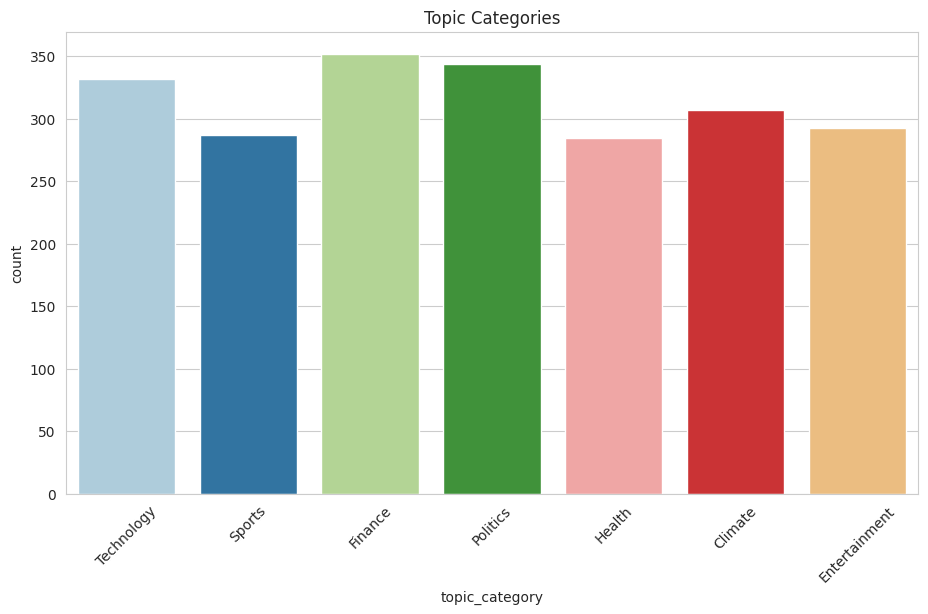

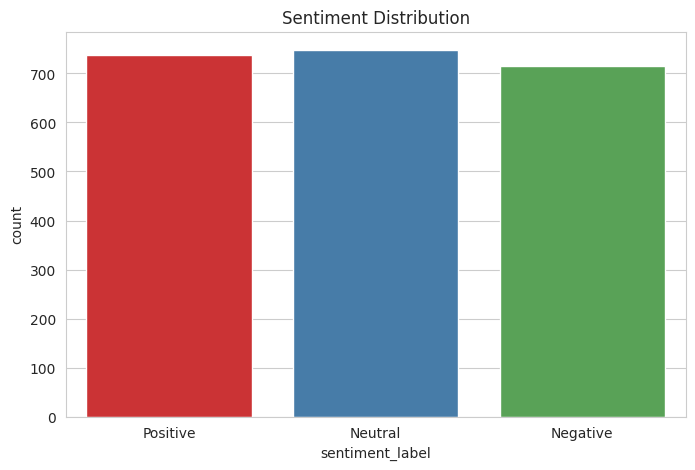

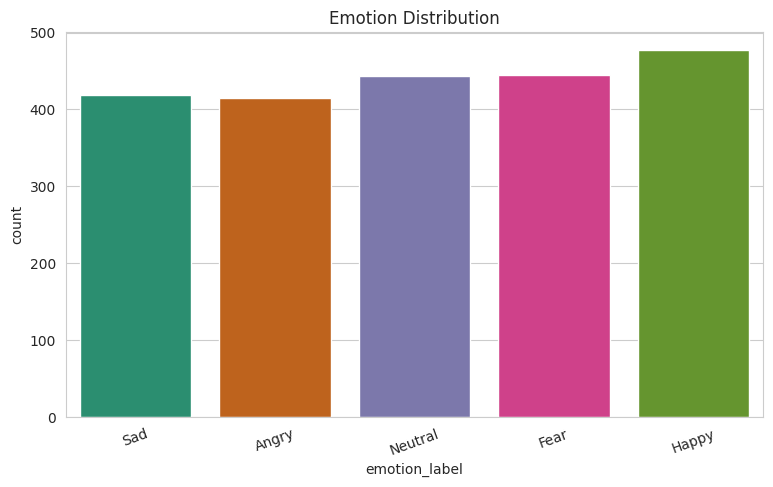

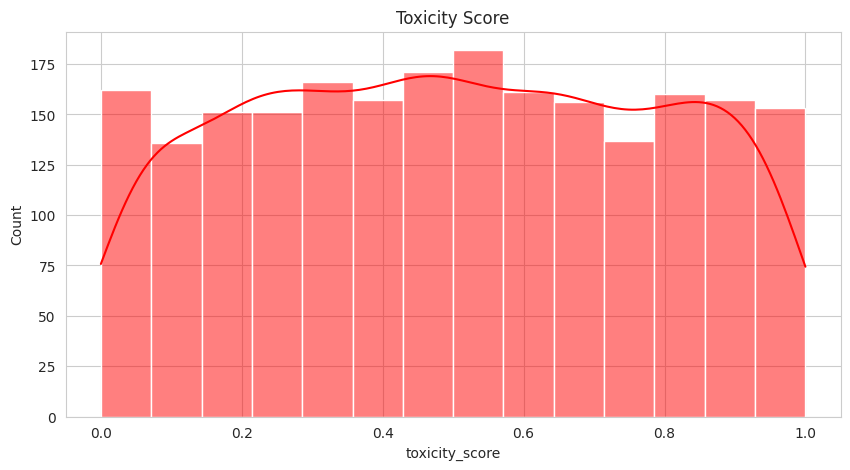

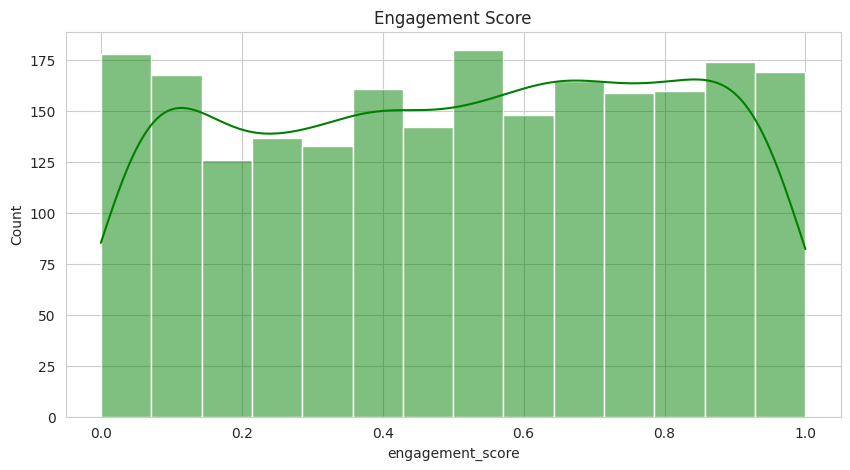

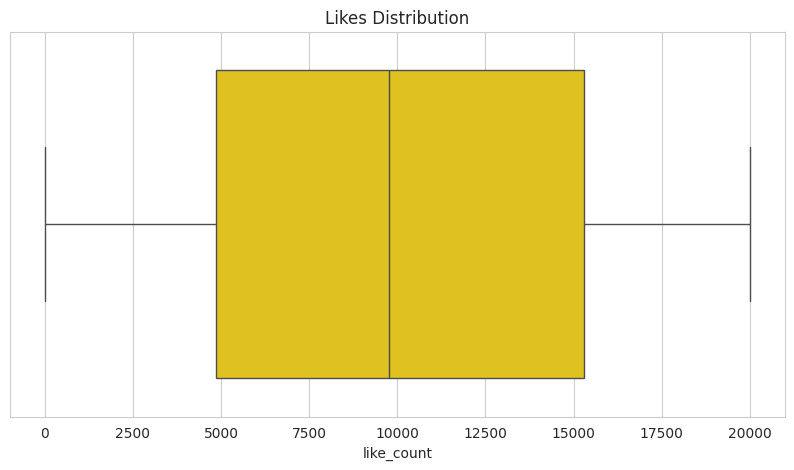

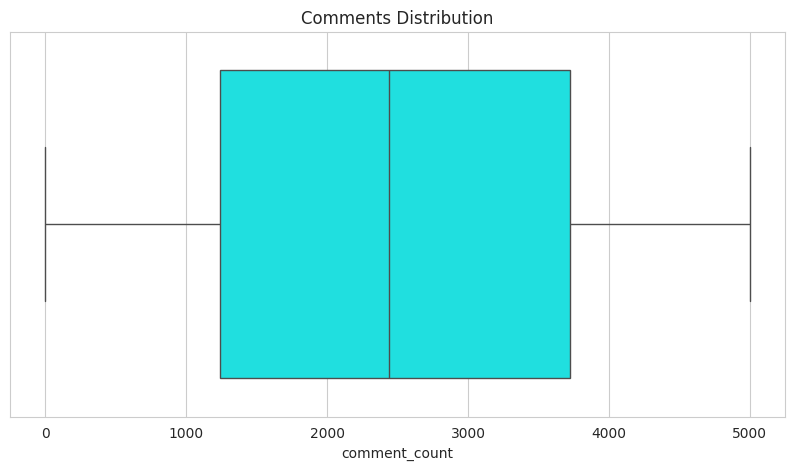

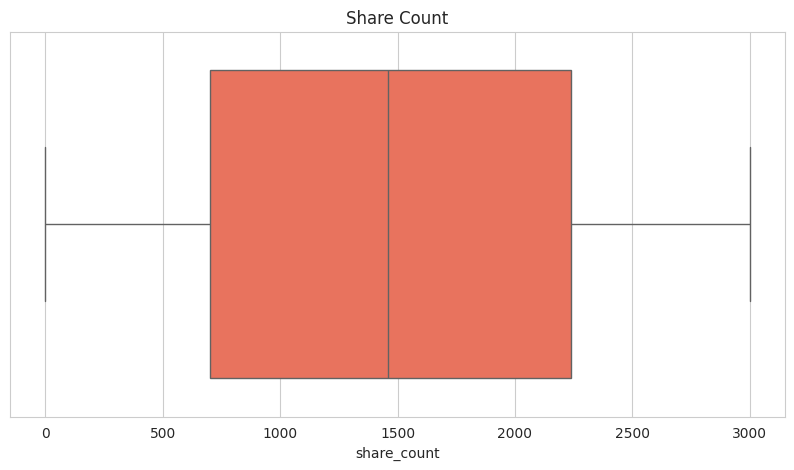

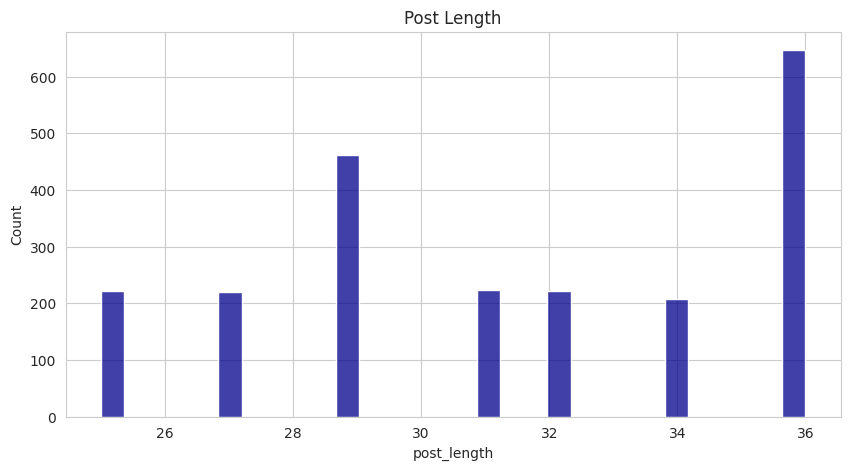

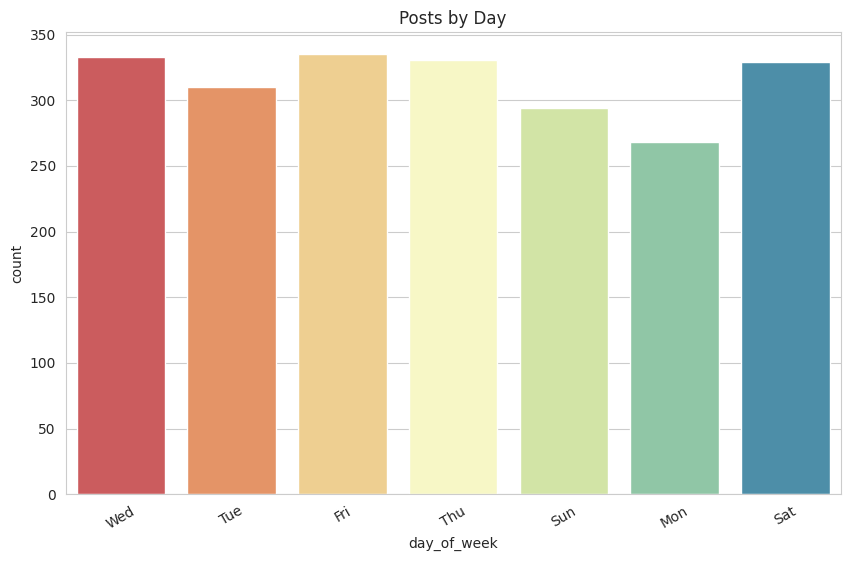

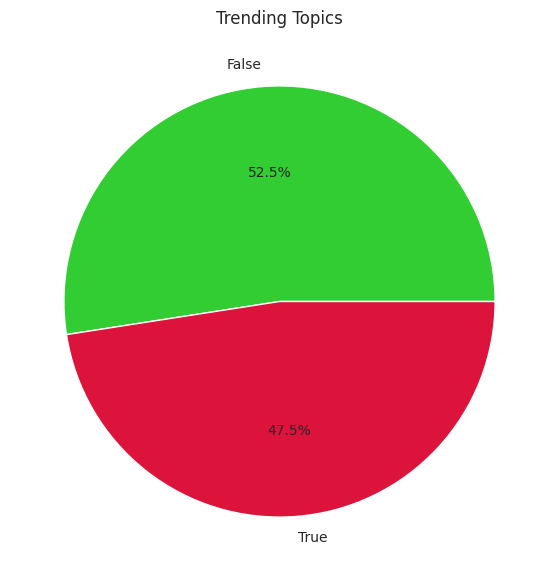

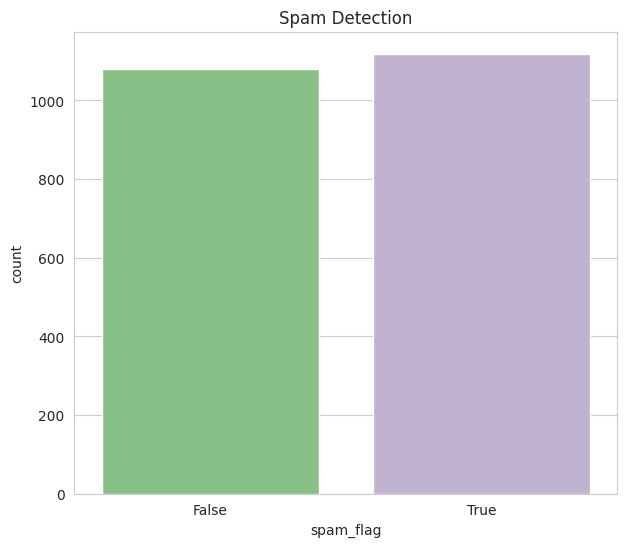

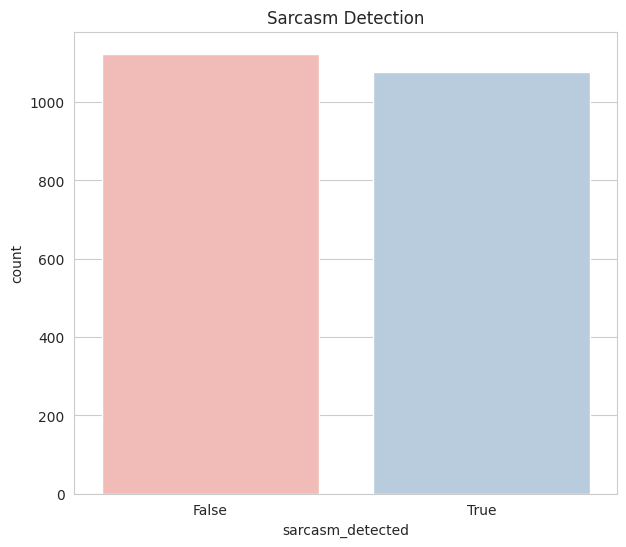

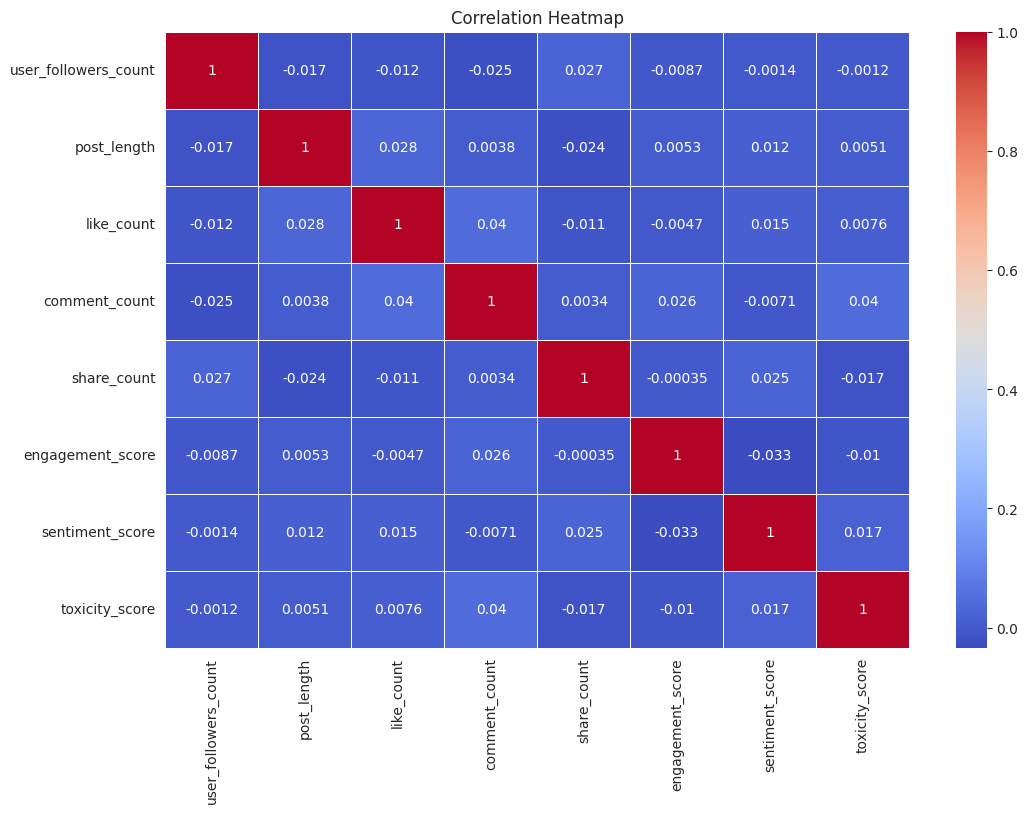

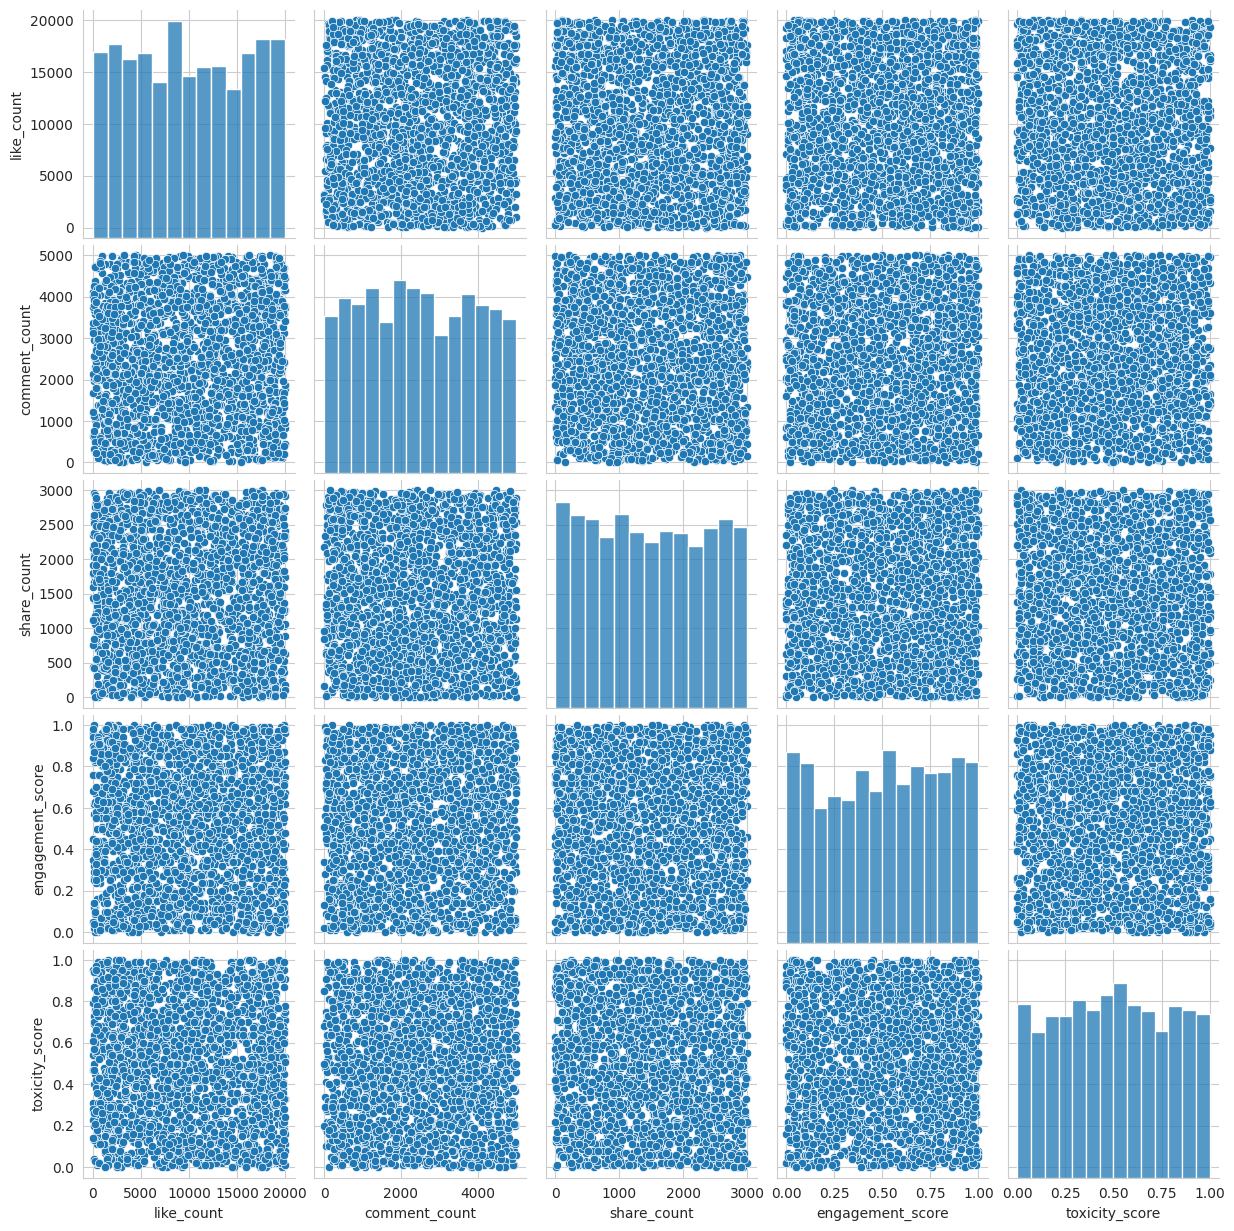

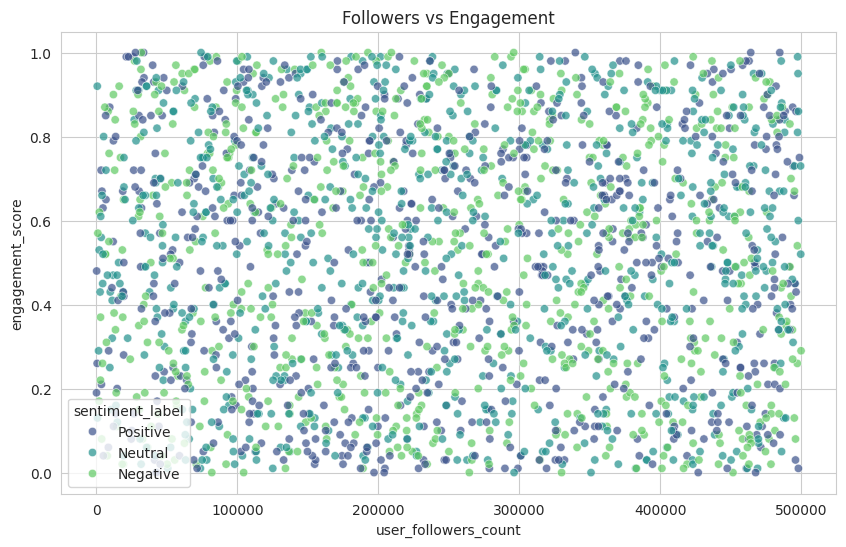

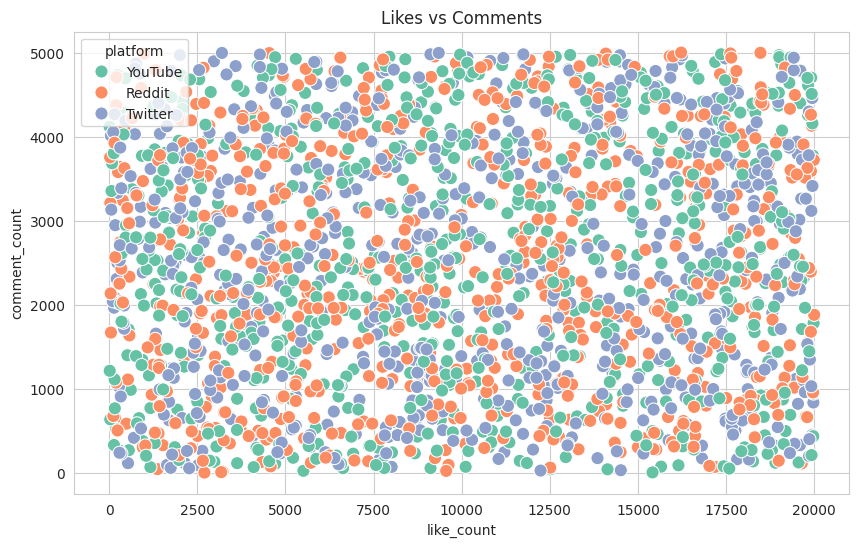

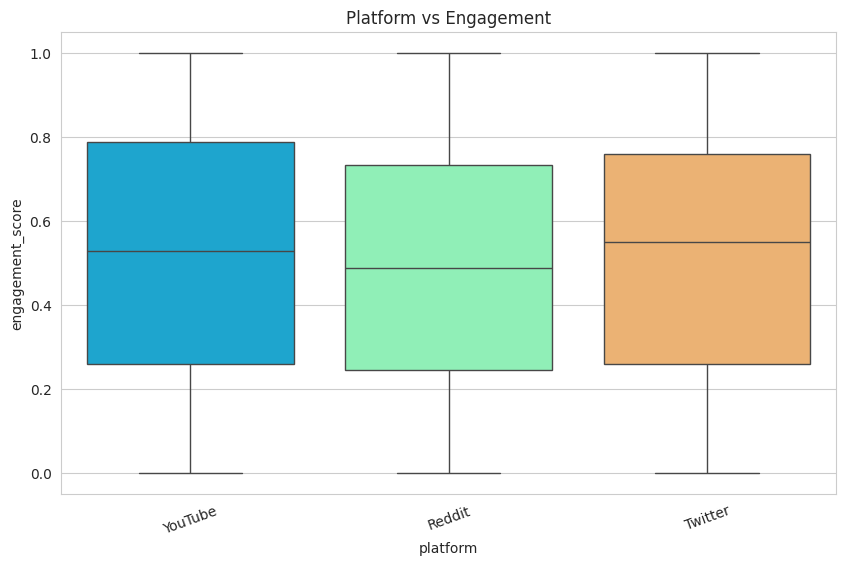

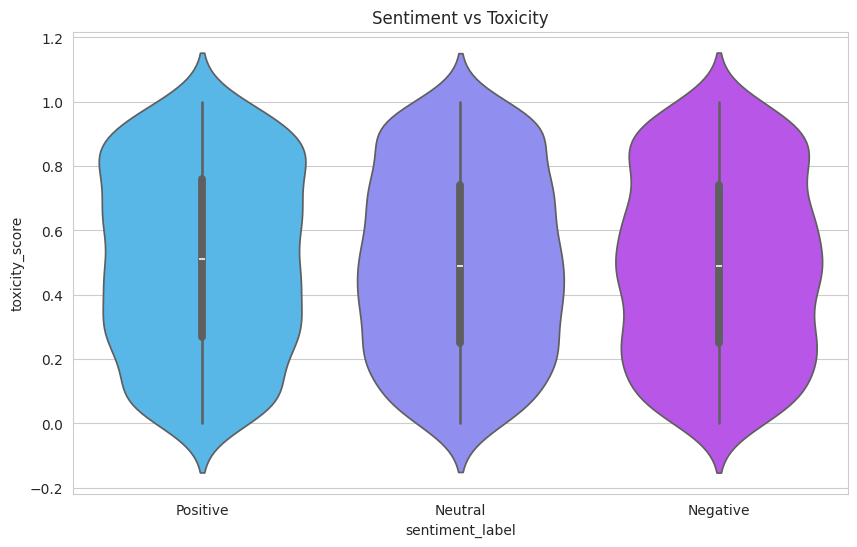

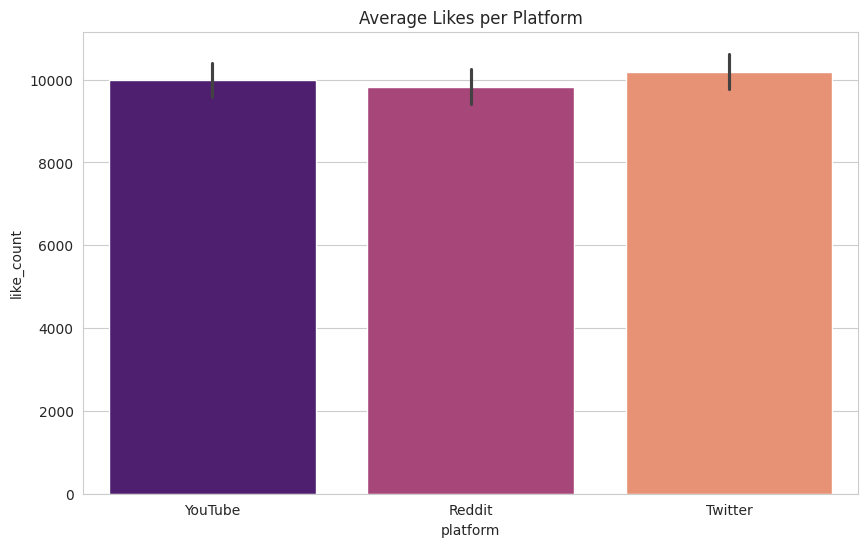

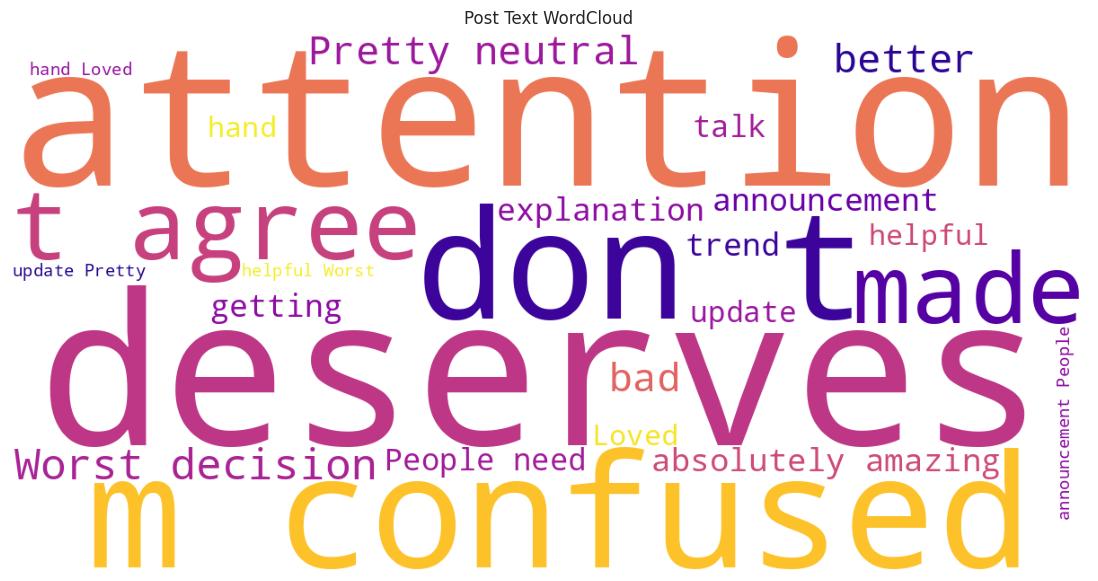

EDA Visualization Completed Successfully.


In [14]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)

# ===========================================================
# Missing Values
# ===========================================================

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap",fontsize=18)
plt.show()

# ===========================================================
# Platform Distribution
# ===========================================================

plt.figure(figsize=(9,6))

sns.countplot(
    data=df,
    x="platform",
    palette="Set2"
)

plt.title("Platform Distribution",fontsize=18)
plt.xticks(rotation=20)
plt.show()

# ===========================================================
# Verified Users
# ===========================================================

plt.figure(figsize=(7,7))

df["user_verified"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue","orange"]
)

plt.ylabel("")
plt.title("Verified Users")
plt.show()

# ===========================================================
# Followers Count Distribution
# ===========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["user_followers_count"],
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Followers Count Distribution")
plt.show()

# ===========================================================
# Top User Locations
# ===========================================================

plt.figure(figsize=(12,6))

df["user_location"].value_counts().head(15).plot(
    kind="bar",
    color="teal"
)

plt.title("Top User Locations")
plt.xticks(rotation=45)
plt.show()

# ===========================================================
# Languages
# ===========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="language",
    palette="coolwarm",
    order=df["language"].value_counts().index
)

plt.title("Languages")
plt.show()

# ===========================================================
# Topic Categories
# ===========================================================

plt.figure(figsize=(11,6))

sns.countplot(
    data=df,
    x="topic_category",
    palette="Paired"
)

plt.xticks(rotation=45)
plt.title("Topic Categories")
plt.show()

# ===========================================================
# Sentiment Labels
# ===========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sentiment_label",
    palette="Set1"
)

plt.title("Sentiment Distribution")
plt.show()

# ===========================================================
# Emotion Labels
# ===========================================================

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="emotion_label",
    palette="Dark2"
)

plt.xticks(rotation=20)
plt.title("Emotion Distribution")
plt.show()

# ===========================================================
# Toxicity Score
# ===========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["toxicity_score"],
    kde=True,
    color="red"
)

plt.title("Toxicity Score")
plt.show()

# ===========================================================
# Engagement Score
# ===========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["engagement_score"],
    kde=True,
    color="green"
)

plt.title("Engagement Score")
plt.show()

# ===========================================================
# Likes Distribution
# ===========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["like_count"],
    color="gold"
)

plt.title("Likes Distribution")
plt.show()

# ===========================================================
# Comments Distribution
# ===========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["comment_count"],
    color="cyan"
)

plt.title("Comments Distribution")
plt.show()

# ===========================================================
# Shares Distribution
# ===========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["share_count"],
    color="tomato"
)

plt.title("Share Count")
plt.show()

# ===========================================================
# Post Length
# ===========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["post_length"],
    bins=30,
    color="darkblue"
)

plt.title("Post Length")
plt.show()

# ===========================================================
# Day of Week
# ===========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="day_of_week",
    palette="Spectral"
)

plt.xticks(rotation=30)
plt.title("Posts by Day")
plt.show()

# ===========================================================
# Trending Topic
# ===========================================================

plt.figure(figsize=(7,7))

df["is_trending_topic"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["limegreen","crimson"]
)

plt.ylabel("")
plt.title("Trending Topics")
plt.show()

# ===========================================================
# Spam Flag
# ===========================================================

plt.figure(figsize=(7,6))

sns.countplot(
    data=df,
    x="spam_flag",
    palette="Accent"
)

plt.title("Spam Detection")
plt.show()

# ===========================================================
# Sarcasm
# ===========================================================

plt.figure(figsize=(7,6))

sns.countplot(
    data=df,
    x="sarcasm_detected",
    palette="Pastel1"
)

plt.title("Sarcasm Detection")
plt.show()

# ===========================================================
# Correlation Heatmap
# ===========================================================

numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=.5
)

plt.title("Correlation Heatmap")
plt.show()

# ===========================================================
# Pairplot
# ===========================================================

sns.pairplot(
    df[[
        "like_count",
        "comment_count",
        "share_count",
        "engagement_score",
        "toxicity_score"
    ]],
    palette="husl"
)

plt.show()

# ===========================================================
# Followers vs Engagement
# ===========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="user_followers_count",
    y="engagement_score",
    hue="sentiment_label",
    palette="viridis",
    alpha=.7
)

plt.title("Followers vs Engagement")
plt.show()

# ===========================================================
# Likes vs Comments
# ===========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="like_count",
    y="comment_count",
    hue="platform",
    palette="Set2",
    s=90
)

plt.title("Likes vs Comments")
plt.show()

# ===========================================================
# Engagement by Platform
# ===========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="platform",
    y="engagement_score",
    palette="rainbow"
)

plt.title("Platform vs Engagement")
plt.xticks(rotation=20)
plt.show()

# ===========================================================
# Sentiment vs Toxicity
# ===========================================================

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="sentiment_label",
    y="toxicity_score",
    palette="cool"
)

plt.title("Sentiment vs Toxicity")
plt.show()

# ===========================================================
# Platform vs Likes
# ===========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="platform",
    y="like_count",
    palette="magma",
    estimator=np.mean
)

plt.title("Average Likes per Platform")
plt.show()

# ===========================================================
# Word Cloud
# ===========================================================

text=" ".join(df["post_text"].astype(str))

wc=WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="plasma"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.title("Post Text WordCloud")
plt.show()

# ===========================================================
# Plotly Interactive Scatter
# ===========================================================

fig=px.scatter(
    df,
    x="like_count",
    y="engagement_score",
    color="platform",
    size="comment_count",
    hover_data=["username","sentiment_label"],
    title="Interactive Engagement Analysis",
    color_discrete_sequence=px.colors.qualitative.Dark24
)

fig.show()

# ===========================================================
# Plotly Sunburst
# ===========================================================

fig=px.sunburst(
    df,
    path=["platform","topic_category","sentiment_label"],
    color="engagement_score",
    color_continuous_scale="Turbo"
)

fig.show()

# ===========================================================
# Plotly Treemap
# ===========================================================

fig=px.treemap(
    df,
    path=["platform","emotion_label"],
    values="engagement_score",
    color="engagement_score",
    color_continuous_scale="Viridis"
)

fig.show()

# ===========================================================
# Plotly Box Plot
# ===========================================================

fig=px.box(
    df,
    x="platform",
    y="engagement_score",
    color="platform",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.show()

# ===========================================================
# Plotly Histogram
# ===========================================================

fig=px.histogram(
    df,
    x="engagement_score",
    color="sentiment_label",
    nbins=40,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.show()

print("EDA Visualization Completed Successfully.")

## Feature enginerring

In [15]:
# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize

Training Shape : (1760, 18)
Testing Shape : (440, 18)
Logistic Regression

Accuracy : 100.00%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       143
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       147

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440



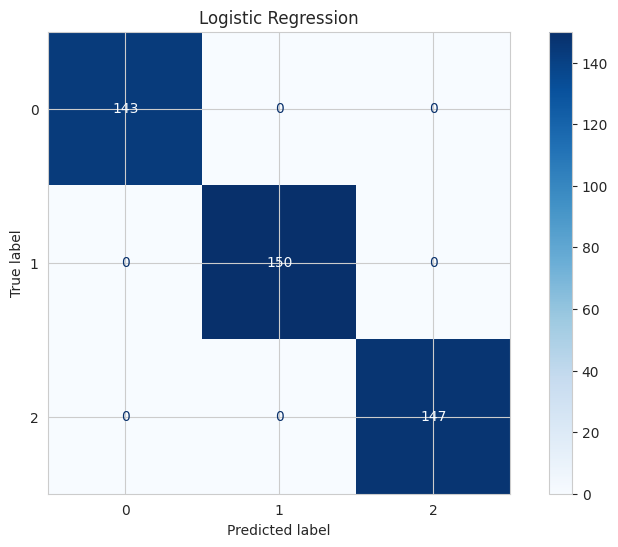

Random Forest

Accuracy : 100.00%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       143
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       147

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440



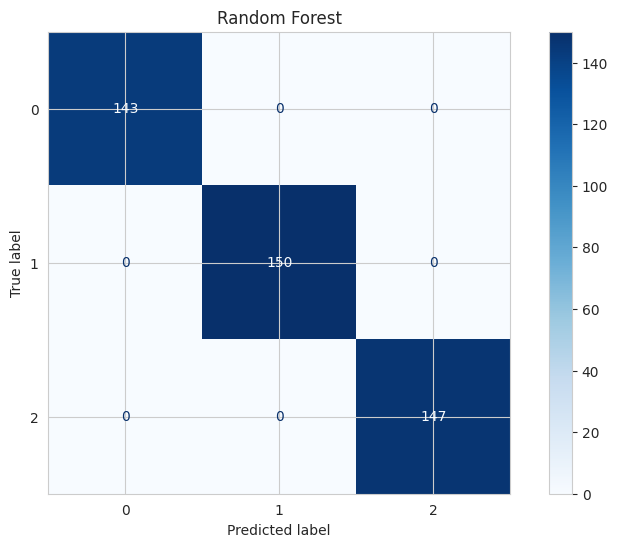

XGBoost

Accuracy : 100.00%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       143
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       147

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440



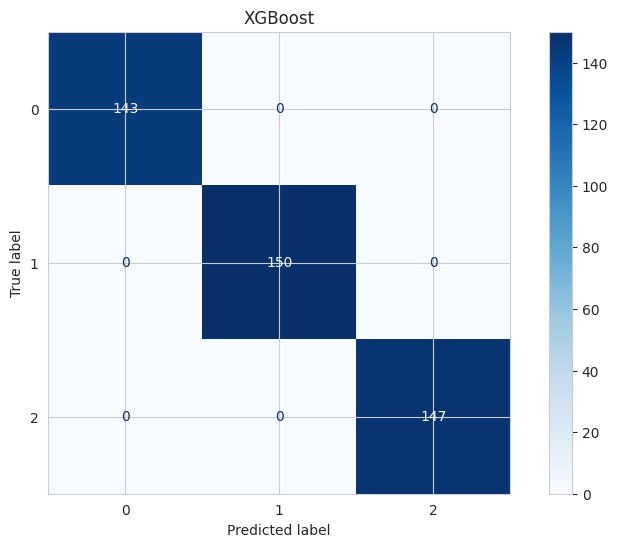


Accuracy Comparison

Logistic Regression = 100.0 %
Random Forest = 100.0 %
XGBoost = 100.0 %


In [16]:
drop_cols = [
    "post_id",
    "user_id",
    "username",
    "post_text",
    "hashtags",
    "mentions",
    "posted_datetime",
    "data_source_url"
]

df = df.drop(columns=drop_cols, errors="ignore")

# ======================================================
# Fill Missing Values
# ======================================================

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=df[col].fillna(df[col].mode()[0])

    else:

        df[col]=df[col].fillna(df[col].median())

# ======================================================
# Label Encoding
# ======================================================

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=encoder.fit_transform(df[col].astype(str))

# ======================================================
# Features & Target
# ======================================================

X=df.drop("sentiment_label",axis=1)

y=df["sentiment_label"]

# ======================================================
# Train Test Split
# ======================================================

X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("Training Shape :",X_train.shape)
print("Testing Shape :",X_test.shape)

# ======================================================
# Feature Scaling
# ======================================================

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

# ======================================================
# Models
# ======================================================

models={

    "Logistic Regression":

        LogisticRegression(max_iter=1000),

    "Random Forest":

        RandomForestClassifier(

            n_estimators=200,
            random_state=42
        ),

    "XGBoost":

        XGBClassifier(

            random_state=42,
            eval_metric="mlogloss"
        )

}

accuracy_dict={}

# ======================================================
# Training
# ======================================================

for name,model in models.items():

    print("="*60)
    print(name)

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)

    accuracy_dict[name]=acc

    print()

    print("Accuracy : {:.2f}%".format(acc*100))

    print()

    print(classification_report(y_test,pred))

    cm=confusion_matrix(y_test,pred)

    disp=ConfusionMatrixDisplay(cm)

    disp.plot(cmap="Blues")

    plt.title(name)

    plt.show()

# ======================================================
# Accuracy Comparison
# ======================================================

print("\nAccuracy Comparison\n")

for k,v in accuracy_dict.items():

    print(k,"=",round(v*100,2),"%")



Best Model : Logistic Regression


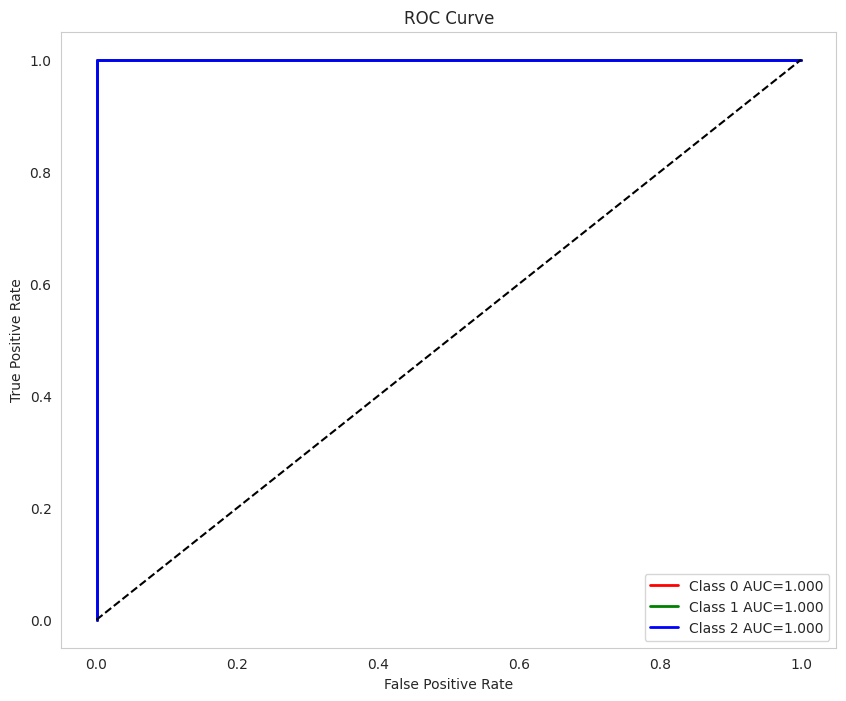

In [17]:
# ======================================================
# Best Model
# ======================================================

best_model_name=max(

    accuracy_dict,
    key=accuracy_dict.get

)

print()

print("Best Model :",best_model_name)

best_model=models[best_model_name]

# ======================================================
# ROC Curve
# ======================================================

classes=np.unique(y)

y_test_bin=label_binarize(

    y_test,
    classes=classes

)

prob=best_model.predict_proba(X_test)

plt.figure(figsize=(10,8))

colors=["red","green","blue","purple","orange"]

for i,color in zip(range(len(classes)),colors):

    fpr,tpr,_=roc_curve(

        y_test_bin[:,i],
        prob[:,i]

    )

    roc_auc=auc(fpr,tpr)

    plt.plot(

        fpr,
        tpr,
        color=color,
        lw=2,
        label="Class {} AUC={:.3f}".format(i,roc_auc)

    )

plt.plot(

    [0,1],
    [0,1],
    linestyle="--",
    color="black"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!